In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.inspection import permutation_importance

### Editing the CSVs

In [8]:
data_path = os.path.join(os.getcwd(), "data")
files = os.listdir(data_path)

In [24]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    try:
        df_individual["CPP"] = df_individual["MAP"] - df_individual["mean_ICP"]
    except:
        df_individual["CPP"] = df_individual["MAP"] - df_individual["ICP"]

    try:
        df_individual = df_individual.rename(columns={
        "RAP_1min": "RAP",
        "mean_ICP": "ICP",
        "meanAMP": "AMP"
        })
    except:
        pass

    df_individual.to_csv(os.path.join(data_path, file), index=False)

In [25]:
df_individual.head()

,DateTime,RAP,ICP,AMP,MAP,CPP
0,45027.539000,NaN,NaN,NaN,NaN,NaN
1,45027.539694,NaN,0.2838,0.0606,-0.2827,-0.5665
2,45027.540389,NaN,6.2230,0.3577,70.0200,63.7970
3,45027.541083,0.9990,7.7310,0.4139,73.4400,65.7090
4,45027.541777,0.9991,7.7210,0.4150,74.0800,66.3590


### Converting the Datetime Format

In [31]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    df_individual["DateTime"] = pd.to_datetime(df_individual["DateTime"], origin="1899-12-30", unit="D")
    
    df_individual.to_csv(os.path.join(data_path, file), index=False)

In [30]:
df_individual.head()

,DateTime,RAP,ICP,AMP,MAP,CPP
0,2019-01-04 18:19:24.389869664,NaN,NaN,NaN,NaN,NaN
1,2019-01-04 18:20:24.389874257,NaN,13.93,1.891,119.3,105.37
2,2019-01-04 18:21:24.389870685,NaN,13.31,1.842,120.0,106.69
3,2019-01-04 18:22:24.389875277,0.8784,13.87,1.924,117.7,103.83
4,2019-01-04 18:23:24.389871074,0.6063,13.90,1.854,118.8,104.90


### Adding Time-minutes Column

In [39]:
for file in files:
    df_individual = pd.read_csv(os.path.join(data_path, file))
    # converting to datetime
    df_individual["DateTime"] = pd.to_datetime(df_individual["DateTime"])
    df_individual["time_minutes"] = (df_individual["DateTime"] - df_individual["DateTime"].iloc[0]).dt.total_seconds() / 60
    
    df_individual.to_csv(os.path.join(data_path, file), index=False)

### Helper: detect first sustained RAP < 0 event

In [4]:
# Helper: detect first sustained RAP < 0 event

def first_sustained_event_time(df, threshold, consecutive_minutes):
    """
    Returns the first time_minutes at which a sustained RAP < threshold
    episode starts, or None if no sustained event exists.
    """

    rap = df["RAP"].values
    times = df["time_minutes"].values

    below = pd.Series(rap < threshold)

    run_length = 0
    start_idx = None

    for i, val in enumerate(below):
        if pd.isna(rap[i]):
            run_length = 0
            start_idx = None
            continue

        if val:
            if run_length == 0:
                start_idx = i
            run_length += 1

            if run_length >= consecutive_minutes:
                return times[start_idx]
        else:
            run_length = 0
            start_idx = None

    return None

### Helper: basic feature extraction from the first landmark hours

In [5]:
def compute_slope(time_values, signal_values):
    valid = pd.DataFrame({"t": time_values, "y": signal_values}).dropna()
    if len(valid) < 2:
        return np.nan
    return np.polyfit(valid["t"], valid["y"], 1)[0]

def extract_early_features(df_early, window_hours):
    feats = {}
    suffix = f"{window_hours}h"

    # RAP
    feats[f"rap_mean_{suffix}"] = df_early["RAP"].mean()
    feats[f"rap_std_{suffix}"] = df_early["RAP"].std()
    feats[f"rap_min_{suffix}"] = df_early["RAP"].min()
    feats[f"rap_max_{suffix}"] = df_early["RAP"].max()
    feats[f"pct_rap_gt_0_4_{suffix}"] = (df_early["RAP"] > 0.4).mean() * 100
    feats[f"pct_rap_0_to_0_4_{suffix}"] = ((df_early["RAP"] >= 0) & (df_early["RAP"] <= 0.4)).mean() * 100
    feats[f"rap_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["RAP"])

    # ICP
    feats[f"icp_mean_{suffix}"] = df_early["ICP"].mean()
    feats[f"icp_std_{suffix}"] = df_early["ICP"].std()
    feats[f"icp_max_{suffix}"] = df_early["ICP"].max()
    feats[f"pct_icp_gt_20_{suffix}"] = (df_early["ICP"] > 20).mean() * 100
    feats[f"icp_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["ICP"])

    # CPP
    feats[f"cpp_mean_{suffix}"] = df_early["CPP"].mean()
    feats[f"cpp_std_{suffix}"] = df_early["CPP"].std()
    feats[f"cpp_min_{suffix}"] = df_early["CPP"].min()
    feats[f"cpp_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["CPP"])

    # MAP
    feats[f"map_mean_{suffix}"] = df_early["MAP"].mean()
    feats[f"map_std_{suffix}"] = df_early["MAP"].std()
    feats[f"map_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["MAP"])

    # AMP
    feats[f"amp_mean_{suffix}"] = df_early["AMP"].mean()
    feats[f"amp_std_{suffix}"] = df_early["AMP"].std()
    feats[f"amp_slope_{suffix}"] = compute_slope(df_early["time_minutes"], df_early["AMP"])

    return feats

# Analysis for 6 hrs as landmark

### Main Loop

In [6]:
# Project Parameters

LANDMARK_HOURS = 6
LANDMARK_MINUTES = LANDMARK_HOURS * 60

SUSTAINED_MINUTES = 10   # RAP < 0 for 10 consecutive minutes
MIN_REQUIRED_MONITORING_MINUTES = LANDMARK_MINUTES + 1
THRESHOLD = -0.1

In [9]:
rows = []
excluded_early_event = []
excluded_short_followup = []
excluded_bad_file = []

for file in files:
    patient_id = file[:7]

    try:
        df_individual = pd.read_csv(os.path.join(data_path, file))
        # trimming starting and ending nans
        df_individual = df_individual.loc[df_individual["RAP"].first_valid_index() : df_individual["RAP"].last_valid_index()]
        
        max_time = df_individual["time_minutes"].max()

        # must at least pass the landmark
        if max_time <= LANDMARK_MINUTES:
            excluded_short_followup.append(patient_id)
            continue

        # first sustained RAP < 0 event anywhere in record
        first_event_time = first_sustained_event_time(
            df_individual,
            threshold=THRESHOLD,
            consecutive_minutes=SUSTAINED_MINUTES
        )

        # exclude if event happened during or before the LANDMARK_HOURS feature window
        if first_event_time is not None and first_event_time <= LANDMARK_MINUTES:
            excluded_early_event.append(patient_id)
            continue

        # split data
        df_early = df_individual[df_individual["time_minutes"] <= LANDMARK_MINUTES].copy()
        df_late = df_individual[df_individual["time_minutes"] > LANDMARK_MINUTES].copy()

        # need some data in both windows
        if len(df_early) == 0 or len(df_late) == 0:
            excluded_short_followup.append(patient_id)
            continue

        # features only from first LANDMARK_HOURS
        feats = extract_early_features(df_early, LANDMARK_HOURS)

        # survival outcome from AFTER LANDMARK_HOURS
        if first_event_time is not None and first_event_time > LANDMARK_MINUTES:
            event_observed = 1
            time_to_event = first_event_time - LANDMARK_MINUTES
        else:
            event_observed = 0
            time_to_event = df_individual["time_minutes"].max() - LANDMARK_MINUTES

        row = {
            "patient_id": patient_id,
            "time_to_event": time_to_event,
            "event_observed": event_observed
        }
        row.update(feats)

        rows.append(row)

    except Exception as e:
        print(f"Error in {patient_id}: {e}")
        excluded_bad_file.append(patient_id)

In [10]:
print(len(rows))
print(len(excluded_early_event))
print(len(excluded_short_followup))

66
38
5


In [11]:
survival_df = pd.DataFrame(rows)
survival_df.head()

,patient_id,time_to_event,event_observed,rap_mean_6h,rap_std_6h,rap_min_6h,rap_max_6h,pct_rap_gt_0_4_6h,pct_rap_0_to_0_4_6h,rap_slope_6h,...,cpp_mean_6h,cpp_std_6h,cpp_min_6h,cpp_slope_6h,map_mean_6h,map_std_6h,map_slope_6h,amp_mean_6h,amp_std_6h,amp_slope_6h
0,TBI_001,540.000000,1,0.700837,0.394027,-0.8520,0.9995,85.754190,5.865922,0.000084,...,91.964534,27.543517,-16.099,0.000135,104.358775,27.287817,-0.007870,2.071919,0.540767,-0.001417
1,TBI_002,1358.000000,0,0.720120,0.354823,-0.9757,0.9995,84.916201,9.497207,-0.000160,...,74.743902,14.327665,35.749,-0.066492,85.195363,10.777494,-0.039238,5.423042,2.226851,0.009302
2,TBI_008,2290.561632,0,0.533700,0.468508,-0.9928,1.0000,73.109244,12.044818,-0.000095,...,65.514108,3.588095,51.250,0.011027,84.262893,3.089337,0.004911,0.643688,0.124667,0.000132
3,TBI_010,1478.092167,0,0.776731,0.282771,-0.5323,0.9990,88.970588,5.882353,0.000445,...,63.660601,6.881330,40.870,0.013830,79.663184,11.926557,0.099057,4.168157,2.558937,0.028438
4,TBI_012,3014.703667,0,0.689026,0.485765,-0.9629,0.9993,79.661017,7.062147,-0.000053,...,78.666466,7.505671,60.728,-0.018213,78.757252,7.460403,-0.014901,2.020250,0.325908,0.002141


In [12]:
suffix = f"{LANDMARK_HOURS}h"

In [13]:
print(f"Excluded: early event before or at {suffix} =", len(excluded_early_event))
print("Excluded: too short follow-up =", len(excluded_short_followup))
print("Excluded: bad/empty files =", len(excluded_bad_file))
print("Included patients =", len(survival_df))

print(f"Later events after {suffix} =", survival_df["event_observed"].sum())
print("Censored =", (survival_df["event_observed"] == 0).sum())
print(f"Median follow-up after {suffix} (minutes) =", survival_df["time_to_event"].median())

Excluded: early event before or at 6h = 38
Excluded: too short follow-up = 5
Excluded: bad/empty files = 0
Included patients = 66
Later events after 6h = 42
Censored = 24
Median follow-up after 6h (minutes) = 1489.7531876428084


## Kaplan-Meier

### RAP group

In [14]:
kmf = KaplanMeierFitter()

col_name = f"rap_mean_{suffix}"

median_rap = survival_df[col_name].median()

survival_df["rap_group"] = np.where(
    survival_df[col_name] >= median_rap,
    f"High early RAP mean ({suffix})",
    f"Low early RAP mean ({suffix})"
)

In [15]:
survival_df.head()

,patient_id,time_to_event,event_observed,rap_mean_6h,rap_std_6h,rap_min_6h,rap_max_6h,pct_rap_gt_0_4_6h,pct_rap_0_to_0_4_6h,rap_slope_6h,...,cpp_std_6h,cpp_min_6h,cpp_slope_6h,map_mean_6h,map_std_6h,map_slope_6h,amp_mean_6h,amp_std_6h,amp_slope_6h,rap_group
0,TBI_001,540.000000,1,0.700837,0.394027,-0.8520,0.9995,85.754190,5.865922,0.000084,...,27.543517,-16.099,0.000135,104.358775,27.287817,-0.007870,2.071919,0.540767,-0.001417,High early RAP mean (6h)
1,TBI_002,1358.000000,0,0.720120,0.354823,-0.9757,0.9995,84.916201,9.497207,-0.000160,...,14.327665,35.749,-0.066492,85.195363,10.777494,-0.039238,5.423042,2.226851,0.009302,High early RAP mean (6h)
2,TBI_008,2290.561632,0,0.533700,0.468508,-0.9928,1.0000,73.109244,12.044818,-0.000095,...,3.588095,51.250,0.011027,84.262893,3.089337,0.004911,0.643688,0.124667,0.000132,Low early RAP mean (6h)
3,TBI_010,1478.092167,0,0.776731,0.282771,-0.5323,0.9990,88.970588,5.882353,0.000445,...,6.881330,40.870,0.013830,79.663184,11.926557,0.099057,4.168157,2.558937,0.028438,High early RAP mean (6h)
4,TBI_012,3014.703667,0,0.689026,0.485765,-0.9629,0.9993,79.661017,7.062147,-0.000053,...,7.505671,60.728,-0.018213,78.757252,7.460403,-0.014901,2.020250,0.325908,0.002141,High early RAP mean (6h)


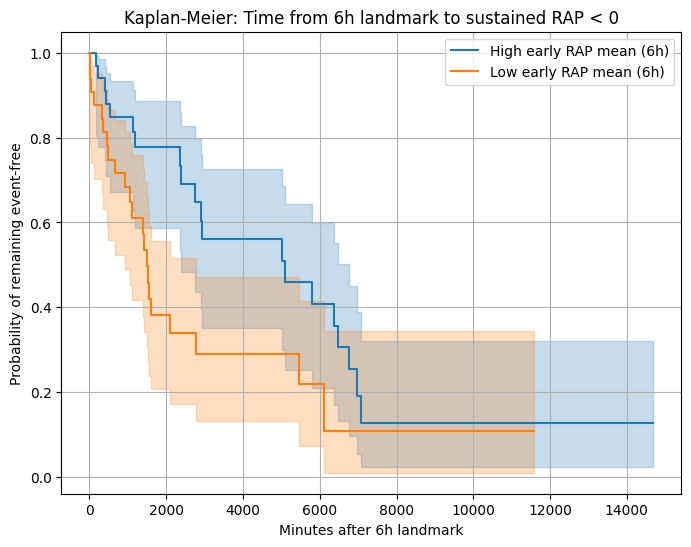

In [16]:
plt.figure(figsize=(8, 6))

for group_name, group_df in survival_df.groupby("rap_group"):
    kmf.fit(
        durations=group_df["time_to_event"],
        event_observed=group_df["event_observed"],
        label=group_name
    )
    kmf.plot_survival_function()

plt.title(f"Kaplan-Meier: Time from {suffix} landmark to sustained RAP < 0")
plt.xlabel(f"Minutes after {suffix} landmark")
plt.ylabel("Probability of remaining event-free")
plt.grid(True)
plt.savefig(f"km_curve_{suffix}_rap.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()

In [17]:
g1 = survival_df[survival_df["rap_group"] == f"High early RAP mean ({suffix})"]
g2 = survival_df[survival_df["rap_group"] == f"Low early RAP mean ({suffix})"]

result = logrank_test(
    g1["time_to_event"], g2["time_to_event"],
    event_observed_A=g1["event_observed"],
    event_observed_B=g2["event_observed"]
)

print("Log-rank p-value:", result.p_value)

Log-rank p-value: 0.02828313037593717


In [18]:
kmf.median_survival_time_

np.float64(1501.4142079220169)

### ICP group

In [19]:
icp_col = f"icp_mean_{suffix}"
median_icp = survival_df[icp_col].median()

survival_df["icp_group"] = np.where(
    survival_df[icp_col] >= median_icp,
    f"High ICP ({suffix})",
    f"Low ICP ({suffix})"
)

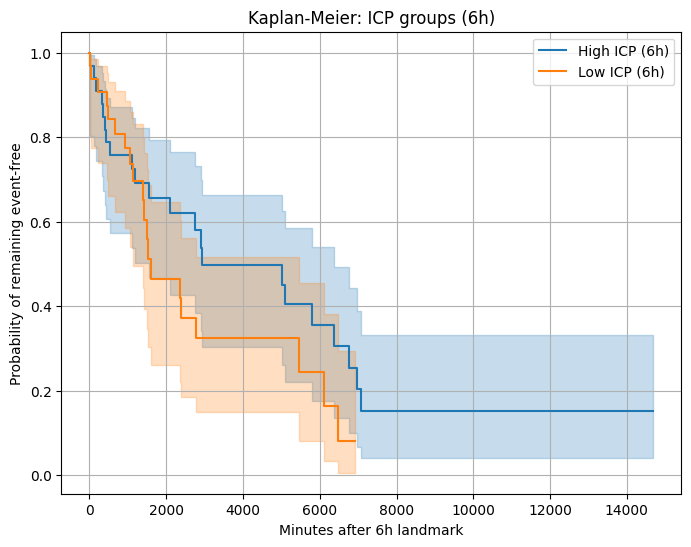

In [20]:
plt.figure(figsize=(8, 6))

for group_name, group_df in survival_df.groupby("icp_group"):
    kmf.fit(
        durations=group_df["time_to_event"],
        event_observed=group_df["event_observed"],
        label=group_name
    )
    kmf.plot_survival_function()

plt.title(f"Kaplan-Meier: ICP groups ({suffix})")
plt.xlabel(f"Minutes after {suffix} landmark")
plt.ylabel("Probability of remaining event-free")
plt.grid(True)
plt.savefig(f"km_curve_{suffix}_icp.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()

In [21]:
g1 = survival_df[survival_df["icp_group"] == f"High ICP ({suffix})"]
g2 = survival_df[survival_df["icp_group"] == f"Low ICP ({suffix})"]

result = logrank_test(
    g1["time_to_event"], g2["time_to_event"],
    event_observed_A=g1["event_observed"],
    event_observed_B=g2["event_observed"]
)

print("Log-rank p-value:", result.p_value)

Log-rank p-value: 0.21218528306964768


In [22]:
kmf.median_survival_time_

np.float64(1597.60205539185)

## Cox proportional hazards model

### For all the physiological variables set

In [23]:
cox_cols = [
    "time_to_event",
    "event_observed",
    f"rap_mean_{suffix}",
    f"icp_mean_{suffix}",
    f"cpp_mean_{suffix}",
    f"map_mean_{suffix}",
    f"amp_mean_{suffix}"
]

cox_df = survival_df[cox_cols].dropna().copy()
cox_df.head()

,time_to_event,event_observed,rap_mean_6h,icp_mean_6h,cpp_mean_6h,map_mean_6h,amp_mean_6h
0,540.000000,1,0.700837,12.478347,91.964534,104.358775,2.071919
1,1358.000000,0,0.720120,10.451461,74.743902,85.195363,5.423042
2,2290.561632,0,0.533700,18.750508,65.514108,84.262893,0.643688
3,1478.092167,0,0.776731,16.004948,63.660601,79.663184,4.168157
4,3014.703667,0,0.689026,-0.186855,78.666466,78.757252,2.020250


In [24]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time_to_event", event_col="event_observed")
cph.print_summary()
cph.summary[["coef", "exp(coef)", "p"]]

C:\Users\abrar\anaconda3\envs\surv_env\lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 64 total observations, 23 right-censored observations>
             duration col = 'time_to_event'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 64
number of events observed = 41
   partial log-likelihood = -239.68
         time fit was run = 2026-04-21 04:35:53 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
rap_mean_6h -1.29      0.28      1.55           -4.32            1.74                0.01                5.69
icp_mean_6h  0.91      2.48      0.19            0.54            1.28                1.71                3.59
cpp_mean_6h  0.95      2.59      0.19            0.57            1.33                1.77                3.79
map_mean_6h -0.95      0.39      0.19           -1.33           -0.57                0.26                0.57
amp_mean_6h -0.17      0.84      0.19           -0.53            0.20                0.59                1.22

             cmp to     z      p  -log2(p)
covariate                                 
rap_mean_6h    0.00 -0.83   0.40      1.31
icp_mean_6h    0.00  4.81 <0.005     19.33
cpp_mean_6h    0.00  4.92 <0.005     20.17
map_mean_6h    0.00 -4.91 <0.005     20.08
amp_mean_6h    0.00 -0.90   0.37      1.45
---
Concordance = 0.53
Partial AIC = 489.35
log-likelihood ratio test = -211.03 on 5 df
-log2(p) of ll-ratio test = -0.00

,coef,exp(coef),p
covariate,,,
rap_mean_6h,-1.289638,0.275370,4.040031e-01
icp_mean_6h,0.908392,2.480331,1.521422e-06
cpp_mean_6h,0.953155,2.593881,8.479985e-07
map_mean_6h,-0.949614,0.386890,9.014140e-07
amp_mean_6h,-0.168555,0.844884,3.663790e-01


In [25]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 64 total observations, 23 right-censored observations>
         test_name = proportional_hazard_test

---
                  test_statistic      p  -log2(p)
amp_mean_6h km            184.91 <0.005    137.49
            rank          227.57 <0.005    168.41
cpp_mean_6h km            750.09 <0.005    546.18
            rank          932.82 <0.005    678.15
icp_mean_6h km            716.39 <0.005    521.84
            rank          890.01 <0.005    647.24
map_mean_6h km            752.98 <0.005    548.27
            rank          936.26 <0.005    680.63
rap_mean_6h km            166.12 <0.005    123.85
            rank          202.68 <0.005    150.37



1. Variable 'rap_mean_6h' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'rap_mean_6h' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'rap_mean_6h' using pd.cut, and then specify it in
`strata=['rap_mean_6h', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'icp_mean_6h' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'icp_mean_6h' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to sp

[]

In [26]:
survival_df.to_csv(f"patient_level_survival_dataset_{suffix}.csv", index=False)
cph.summary.to_csv(f"cox_summary_{suffix}.csv")

In [27]:
print("C-index:", cph.concordance_index_)

C-index: 0.53125


### For RAP set variables

In [28]:
cox_cols = [
    "time_to_event",
    "event_observed",
    f"rap_mean_{suffix}",
    f"rap_std_{suffix}",
    f"pct_rap_gt_0_4_{suffix}",
    f"pct_rap_0_to_0_4_{suffix}"
]

cox_df = survival_df[cox_cols].dropna().copy()
cox_df.head()

,time_to_event,event_observed,rap_mean_6h,rap_std_6h,pct_rap_gt_0_4_6h,pct_rap_0_to_0_4_6h
0,540.000000,1,0.700837,0.394027,85.754190,5.865922
1,1358.000000,0,0.720120,0.354823,84.916201,9.497207
2,2290.561632,0,0.533700,0.468508,73.109244,12.044818
3,1478.092167,0,0.776731,0.282771,88.970588,5.882353
4,3014.703667,0,0.689026,0.485765,79.661017,7.062147


In [29]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time_to_event", event_col="event_observed")
cph.print_summary()
cph.summary[["coef", "exp(coef)", "p"]]

<lifelines.CoxPHFitter: fitted with 66 total observations, 24 right-censored observations>
             duration col = 'time_to_event'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 66
number of events observed = 42
   partial log-likelihood = -134.34
         time fit was run = 2026-04-21 04:36:22 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
rap_mean_6h         -3.10      0.05      1.35           -5.75           -0.45                0.00                0.63
rap_std_6h           0.01      1.01      2.36           -4.62            4.64                0.01              103.62
pct_rap_gt_0_4_6h    0.01      1.01      0.02           -0.02            0.04                0.98                1.04
pct_rap_0_to_0_4_6h  0.01      1.01      0.04           -0.07            0.09                0.94                1.09

                     cmp to     z    p  -log2(p)
covariate                                       
rap_mean_6h            0.00 -2.30 0.02      5.53
rap_std_6h             0.00  0.00 1.00      0.00
pct_rap_gt_0_4_6h      0.00  0.79 0.43      1.21
pct_rap_0_to_0_4_6h    0.00  0.30 0.76      0.39
---
Concordance = 0.65
Partial AIC = 276.69
log-likelihood ratio test = 12.06 on 4 df
-log2(p) of ll-ratio test = 5.88

,coef,exp(coef),p
covariate,,,
rap_mean_6h,-3.100855,0.045011,0.021623
rap_std_6h,0.008358,1.008393,0.997178
pct_rap_gt_0_4_6h,0.012523,1.012601,0.432452
pct_rap_0_to_0_4_6h,0.011874,1.011945,0.764336


In [30]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 66 total observations, 24 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic    p  -log2(p)
pct_rap_0_to_0_4_6h km              1.47 0.23      2.15
                    rank            1.72 0.19      2.40
pct_rap_gt_0_4_6h   km              4.21 0.04      4.63
                    rank            4.27 0.04      4.69
rap_mean_6h         km              2.03 0.15      2.70
                    rank            2.22 0.14      2.87
rap_std_6h          km              0.14 0.71      0.49
                    rank            0.18 0.67      0.58



1. Variable 'pct_rap_gt_0_4_6h' failed the non-proportional test: p-value is 0.0387.

   Advice 1: the functional form of the variable 'pct_rap_gt_0_4_6h' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'pct_rap_gt_0_4_6h' using pd.cut, and then specify it in
`strata=['pct_rap_gt_0_4_6h', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Prop

[]

In [31]:
print("C-index:", cph.concordance_index_)

C-index: 0.6490984743411928


## Random Survival Forest

In [32]:
y = Surv.from_dataframe(
    event="event_observed",
    time="time_to_event",
    data=survival_df
)

## For all the physiological variables set

In [33]:
suffix = f"{LANDMARK_HOURS}h"

feature_cols = [
    f"rap_mean_{suffix}",
    f"icp_mean_{suffix}",
    f"cpp_mean_{suffix}",
    f"map_mean_{suffix}",
    f"amp_mean_{suffix}"
]

X = survival_df[feature_cols].dropna().copy()
y = y[X.index]   # align

In [34]:
rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf

,n_estimators,200
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rsf.fit(X_train, y_train)

cindex_test = concordance_index_censored(
    y_test["event_observed"],
    y_test["time_to_event"],
    rsf.predict(X_test)
)[0]

print("Test C-index:", cindex_test)

Test C-index: 0.6691729323308271


In [36]:
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

print(importance)

rap_mean_6h    0.117293
map_mean_6h    0.025188
amp_mean_6h    0.012030
cpp_mean_6h   -0.000752
icp_mean_6h   -0.032331
dtype: float64


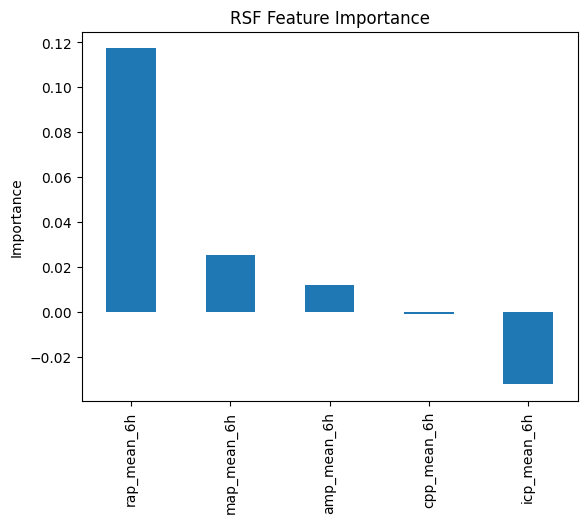

In [37]:
importance.plot(kind="bar")
plt.title("RSF Feature Importance")
plt.ylabel("Importance")
plt.savefig(f"rsf_feat_imp{suffix}_param.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()

### For RAP set variables

In [39]:
y = Surv.from_dataframe(
    event="event_observed",
    time="time_to_event",
    data=survival_df
)

In [40]:
suffix = f"{LANDMARK_HOURS}h"

feature_cols = [
    f"rap_mean_{suffix}",
    f"rap_std_{suffix}",
    f"pct_rap_gt_0_4_{suffix}",
    f"pct_rap_0_to_0_4_{suffix}"
]

X = survival_df[feature_cols].dropna().copy()
y = y[X.index]   # align

In [41]:
rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf

,n_estimators,200
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rsf.fit(X_train, y_train)

cindex_test = concordance_index_censored(
    y_test["event_observed"],
    y_test["time_to_event"],
    rsf.predict(X_test)
)[0]

print("Test C-index:", cindex_test)

Test C-index: 0.6147540983606558


In [43]:
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

print(importance)

rap_mean_6h            0.065984
pct_rap_gt_0_4_6h      0.010246
rap_std_6h            -0.004098
pct_rap_0_to_0_4_6h   -0.029918
dtype: float64


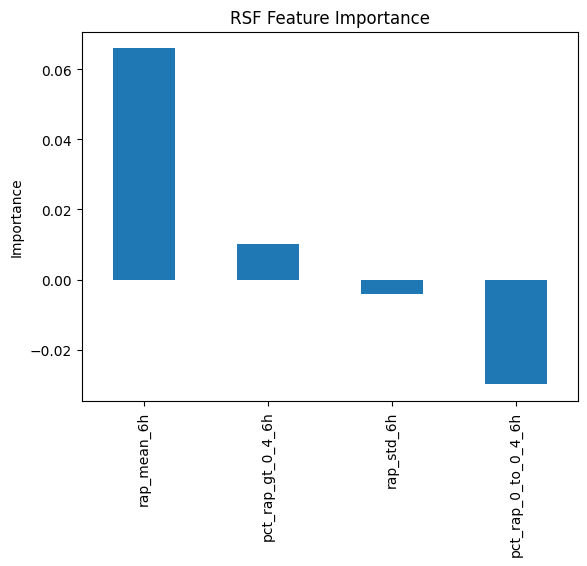

In [44]:
importance.plot(kind="bar")
plt.title("RSF Feature Importance")
plt.ylabel("Importance")
plt.savefig(f"rsf_feat_imp{suffix}_rap.jpg", dpi=300, bbox_inches="tight")  # <-- save here
plt.show()